<h1 style="text-align: center;font-size: 40px;">Cataract Prediction using PPO</h1>

---

<h3>Dataset Information:</h3>
Ocular Disease Intelligent Recognition (ODIR) is a structured ophthalmic database of 5,000 patients with age, color fundus photographs from left and right eyes and doctors' diagnostic keywords.
We classify images into two categories:
<ul>
  <li><b>Normal</b> – healthy fundus images</li>
  <li><b>Cataract</b> – images diagnosed with cataract</li>
</ul>

In [7]:
# Step 1: Download dataset using KaggleHub
import kagglehub
path = kagglehub.dataset_download('andrewmvd/ocular-disease-recognition-odir5k')
print('Path to dataset files:', path)

Path to dataset files: /kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k


In [8]:
# Step 2: Install required libraries
!pip install tensorflow scikit-learn scipy

In [9]:
# Step 3: Import necessary libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [10]:
# Step 4: Define dataset paths
csv_path  = os.path.join(path, 'full_df.csv')
image_dir = os.path.join(path, 'preprocessed_images')
df = pd.read_csv(csv_path)
df.head(3)

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg


In [11]:
# Step 5: Extract Cataract & Normal image paths
def has_cataract(text):
    return 1 if 'cataract' in str(text).lower() else 0

df['left_cataract']  = df['Left-Diagnostic Keywords'].apply(has_cataract)
df['right_cataract'] = df['Right-Diagnostic Keywords'].apply(has_cataract)

left_cataract   = df.loc[(df.C == 1) & (df.left_cataract  == 1)]['Left-Fundus'].values
right_cataract  = df.loc[(df.C == 1) & (df.right_cataract == 1)]['Right-Fundus'].values
cataract_images = np.concatenate((left_cataract, right_cataract), axis=0)

left_normal   = df.loc[(df.C == 0) & (df['Left-Diagnostic Keywords']  == 'normal fundus')]['Left-Fundus'].sample(250, random_state=42).values
right_normal  = df.loc[(df.C == 0) & (df['Right-Diagnostic Keywords'] == 'normal fundus')]['Right-Fundus'].sample(250, random_state=42).values
normal_images = np.concatenate((left_normal, right_normal), axis=0)

print(f'Cataract images : {len(cataract_images)}')
print(f'Normal images   : {len(normal_images)}')

Cataract images : 594
Normal images   : 500


In [43]:
# Step 6: Build DataFrame
import os

# Check which files actually exist on the disk
exists = data_df['filename'].apply(os.path.exists)

# Log the missing count
missing_count = len(data_df) - exists.sum()
if missing_count > 0:
    print(f"Removing {missing_count} missing images from the dataset.")

# Keep only the valid files
data_df = data_df[exists].reset_index(drop=True)
image_paths = (
    [os.path.join(image_dir, img) for img in cataract_images] +
    [os.path.join(image_dir, img) for img in normal_images]
)
labels = ['CATARACT'] * len(cataract_images) + ['NORMAL'] * len(normal_images)

data_df = pd.DataFrame({'filename': image_paths, 'class': labels})
data_df['label'] = data_df['class'].map({'NORMAL': 0, 'CATARACT': 1})

print(data_df['class'].value_counts())
data_df.head()

Removing 6 missing images from the dataset.
class
CATARACT    594
NORMAL      500
Name: count, dtype: int64


,filename,class,label
0,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1
1,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1
2,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1
3,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1
4,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1


<h3>Sample Images from Dataset</h3>

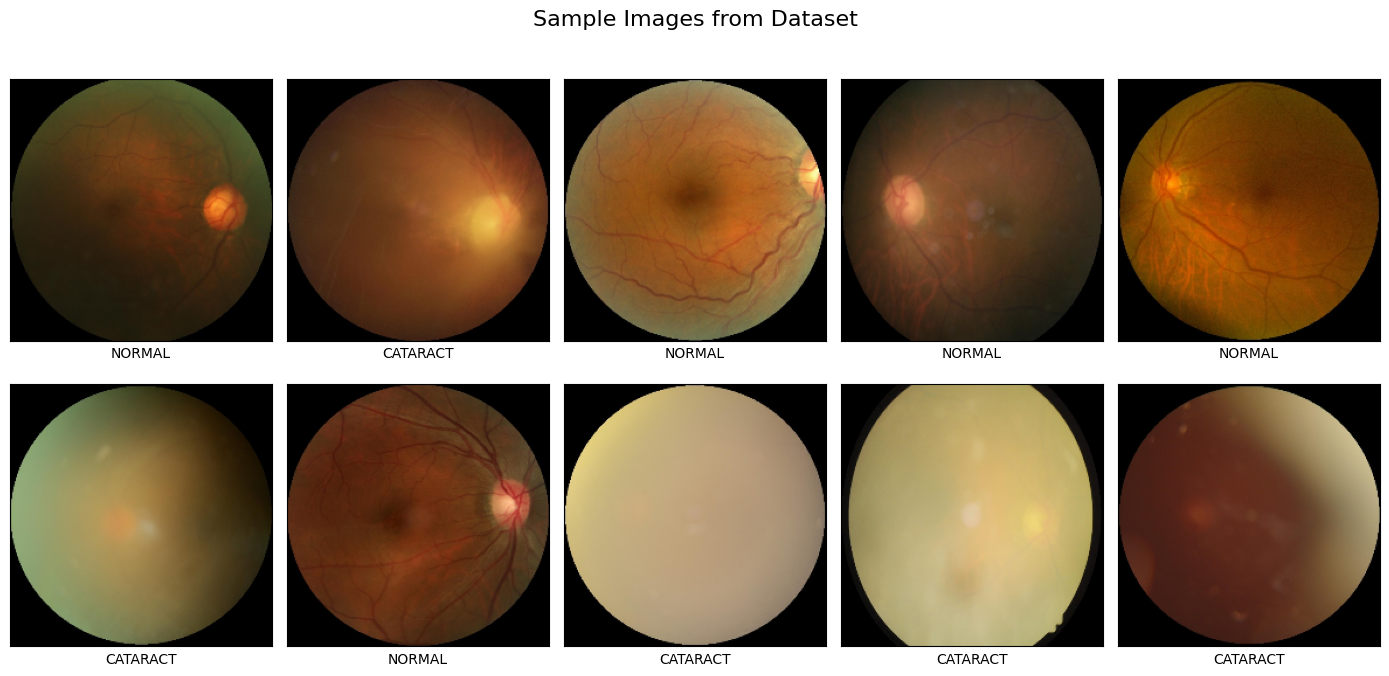

In [44]:
# Step 7: Visualise sample images from dataset
plt.figure(figsize=(14, 7))
sample_rows = data_df.sample(10, random_state=1).reset_index(drop=True)
for i, row in sample_rows.iterrows():
    image = cv2.imread(row['filename'])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.xlabel(row['class'])
    plt.xticks([]); plt.yticks([])
plt.suptitle('Sample Images from Dataset', fontsize=16)
plt.tight_layout()
plt.show()

In [45]:
# Step 8: Train / Validation split
train_df, val_df = train_test_split(
    data_df, test_size=0.2, stratify=data_df['label'], random_state=42
)
print(f'Train size: {len(train_df)} | Val size: {len(val_df)}')

Train size: 875 | Val size: 219


In [46]:
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        # Return a blank image or handle the error
        print(f"Warning: Could not read image at {path}")
        return np.zeros((224, 224, 3), dtype=np.float32) 
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img.astype('float32'))
    return img

In [47]:
# Step 10: Build PPO Actor-Critic Network (shared MobileNetV2 backbone)
def build_ppo_network():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base.layers:
        layer.trainable = False

    x      = GlobalAveragePooling2D()(base.output)
    shared = Dense(256, activation='relu')(x)

    actor  = Dense(2, activation='softmax', name='actor')(shared)
    critic = Dense(1, activation='linear',  name='critic')(shared)

    return Model(inputs=base.input, outputs=[actor, critic])

ppo_model = build_ppo_network()
optimizer = Adam(learning_rate=3e-4)
ppo_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [48]:
# Step 11: PPO Hyperparameters
GAMMA       = 0.99
CLIP_EPS    = 0.2          # PPO clipping range
ENTROPY_BETA = 0.01
PPO_EPOCHS  = 4            # update passes per rollout
ROLLOUT_LEN = 64           # steps per rollout buffer
EPISODES    = 10

In [49]:
def ppo_update(states, actions, returns, old_log_probs, advantages):
    losses = []
    for _ in range(PPO_EPOCHS):
        with tf.GradientTape() as tape:
            probs_all, values_all = ppo_model(states, training=True)
            
            # --- FIX STARTS HERE ---
            # We need to select the probability of the specific action taken for each state
            # Using tf.one_hot and reduce_sum is often cleaner than gather in this context
            action_masks = tf.one_hot(actions, 2) # 2 is the number of actions
            log_probs = tf.math.log(tf.reduce_sum(probs_all * action_masks, axis=1) + 1e-8)
            # --- FIX ENDS HERE ---

            ratio = tf.exp(log_probs - old_log_probs)
            adv_t = tf.cast(advantages, tf.float32)
            
            surr1 = ratio * adv_t
            surr2 = tf.clip_by_value(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * adv_t
            
            actor_loss = -tf.reduce_mean(tf.minimum(surr1, surr2))
            critic_loss = tf.reduce_mean(tf.square(returns - tf.squeeze(values_all)))
            
            # Entropy for exploration
            entropy = -tf.reduce_mean(tf.reduce_sum(probs_all * tf.math.log(probs_all + 1e-8), axis=1))
            
            total_loss = actor_loss + 0.5 * critic_loss - ENTROPY_BETA * entropy
            
        grads = tape.gradient(total_loss, ppo_model.trainable_variables)
        optimizer.apply_gradients(zip(grads, ppo_model.trainable_variables))
        losses.append(float(total_loss))
    return float(np.mean(losses))

In [50]:
# Step 13: Train the PPO agent (Optimized)
train_paths = train_df['filename'].values
train_labels = train_df['label'].values
val_paths_arr = val_df['filename'].values
val_labels_arr = val_df['label'].values

train_acc_history, val_acc_history = [], []
train_loss_history, val_loss_history = [], []

# PRE-LOAD VALIDATION IMAGES (Do this once to save time)
print("Loading validation images...")
val_images = np.array([load_image(p) for p in val_paths_arr])

for episode in range(EPISODES):
    # 1. Collect rollout data
    states, actions, returns, old_log_probs, advantages = collect_rollout(train_paths, train_labels)
    
    # 2. Update the model
    ep_loss = ppo_update(states, actions, returns, old_log_probs, advantages)

    # 3. Calculate Train Accuracy (on the rollout batch)
    probs_out, _ = ppo_model.predict(states, verbose=0)
    tr_preds = np.argmax(probs_out, axis=1)
    tr_acc = float(np.mean(tr_preds == actions))

    # 4. Optimized Validation Pass (Batch Prediction)
    val_probs, _ = ppo_model.predict(val_images, batch_size=32, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    
    val_acc = float(np.mean(val_preds == val_labels_arr))
    val_loss = float(np.mean(tf.keras.losses.sparse_categorical_crossentropy(val_labels_arr, val_probs)))

    # Save History
    train_acc_history.append(tr_acc)
    val_acc_history.append(val_acc)
    train_loss_history.append(ep_loss)
    val_loss_history.append(val_loss)

    print(f'Episode {episode + 1}/{EPISODES} | '
          f'Train Acc: {tr_acc:.4f} | Val Acc: {val_acc:.4f} | Loss: {ep_loss:.4f}')

Loading validation images...


[ WARN:0@1636.248] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images/1456_right.jpg'): can't open/read file: check file path/integrity


[ WARN:0@1636.518] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images/2244_left.jpg'): can't open/read file: check file path/integrity


[ WARN:0@1636.830] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images/2231_left.jpg'): can't open/read file: check file path/integrity


Episode 1/10 | Train Acc: 0.4844 | Val Acc: 0.8219 | Loss: 2.2325
Episode 2/10 | Train Acc: 0.6719 | Val Acc: 0.8995 | Loss: 0.0357
Episode 3/10 | Train Acc: 0.8594 | Val Acc: 0.9087 | Loss: 0.3965
Episode 4/10 | Train Acc: 0.9375 | Val Acc: 0.9224 | Loss: -0.2089


...

Episode 5/10 | Train Acc: 0.8906 | Val Acc: 0.8950 | Loss: 0.6697
Episode 6/10 | Train Acc: 0.9688 | Val Acc: 0.8950 | Loss: -0.1232


[ WARN:0@1939.999] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images/2229_right.jpg'): can't open/read file: check file path/integrity


Episode 7/10 | Train Acc: 0.9375 | Val Acc: 0.8904 | Loss: 0.2831
Episode 8/10 | Train Acc: 0.9844 | Val Acc: 0.8904 | Loss: 0.0882
Episode 9/10 | Train Acc: 0.9219 | Val Acc: 0.9087 | Loss: 0.1993


[ WARN:0@2082.535] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images/2102_left.jpg'): can't open/read file: check file path/integrity


Episode 10/10 | Train Acc: 0.9688 | Val Acc: 0.9132 | Loss: 0.2448


In [52]:
# Step 14: Generate final predictions on validation set
y_pred_prob = []
for vp in val_paths_arr:
    s = load_image(vp)
    probs, _ = ppo_model.predict(s[np.newaxis], verbose=0)
    y_pred_prob.append(float(probs[0][1]))   # probability of CATARACT

y_pred_prob = np.array(y_pred_prob)
y_pred      = (y_pred_prob > 0.5).astype(int)
y_true      = val_labels_arr.astype(int)

[ WARN:0@2173.543] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images/1456_right.jpg'): can't open/read file: check file path/integrity


[ WARN:0@2180.352] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images/2244_left.jpg'): can't open/read file: check file path/integrity


[ WARN:0@2188.824] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images/2231_left.jpg'): can't open/read file: check file path/integrity


<h3>Learning Curve</h3>

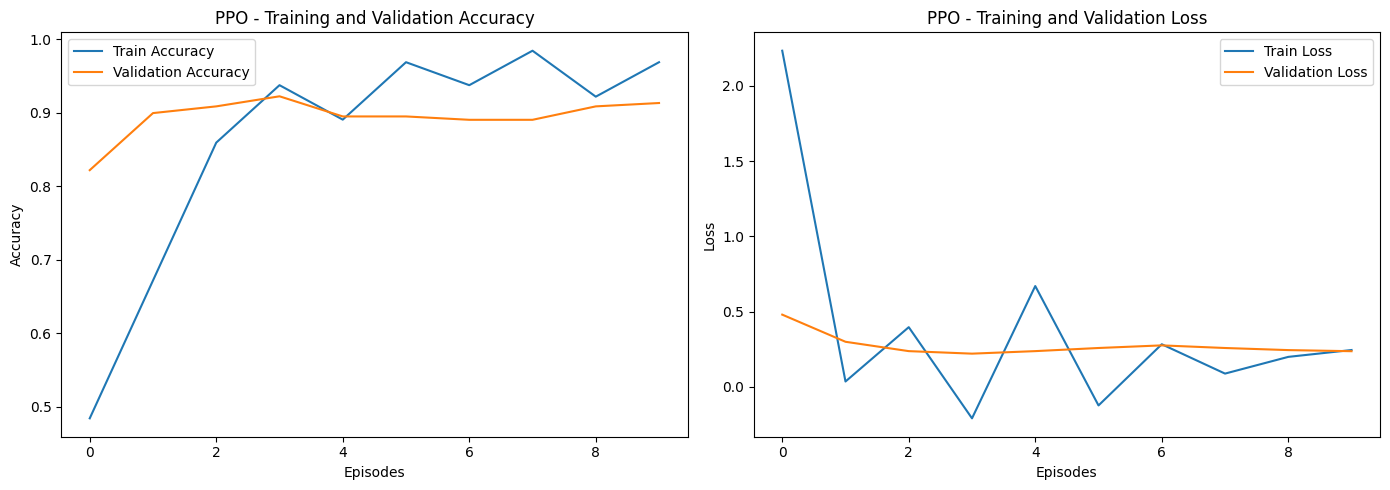

In [53]:
# Plot training history (combined)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_acc_history,  label='Train Accuracy')
plt.plot(val_acc_history,    label='Validation Accuracy')
plt.title('PPO - Training and Validation Accuracy')
plt.xlabel('Episodes')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history,   label='Validation Loss')
plt.title('PPO - Training and Validation Loss')
plt.xlabel('Episodes')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Separate Accuracy & Loss Curves

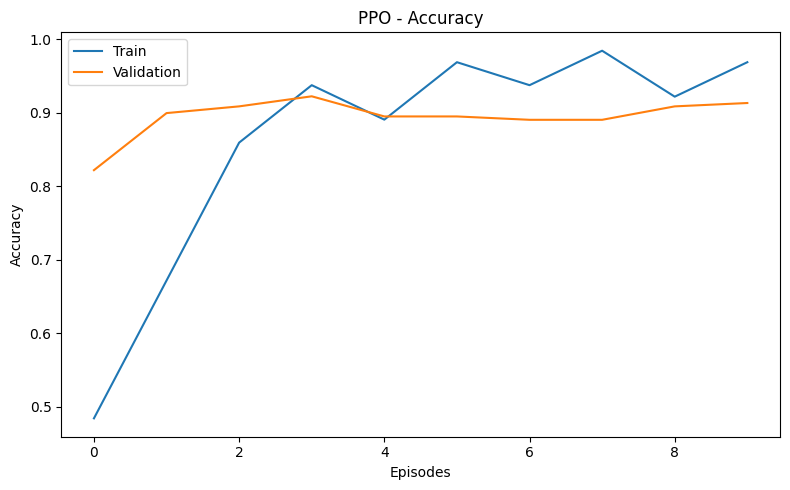

In [55]:
# Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(train_acc_history,  label='Train')
plt.plot(val_acc_history,    label='Validation')
plt.title('PPO - Accuracy')
plt.xlabel('Episodes')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

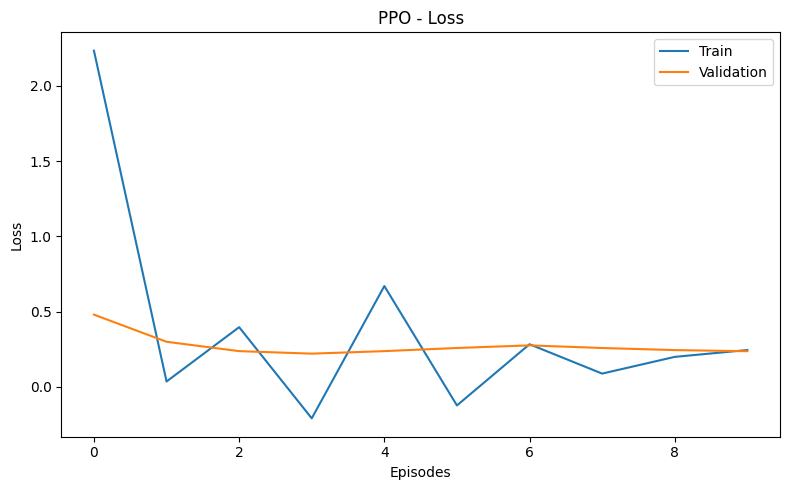

In [56]:
# Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label='Train')
plt.plot(val_loss_history,   label='Validation')
plt.title('PPO - Loss')
plt.xlabel('Episodes')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

<h3>Confusion Matrix</h3>

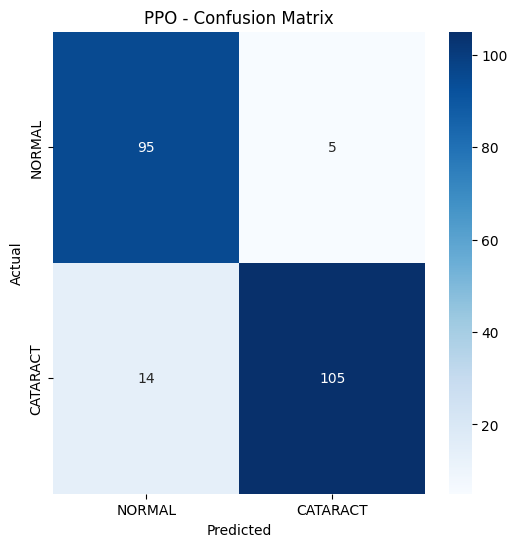

In [57]:
# Confusion Matrix (counts)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'CATARACT'],
            yticklabels=['NORMAL', 'CATARACT'])
plt.title('PPO - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Confusion Matrix — Counts & Normalized

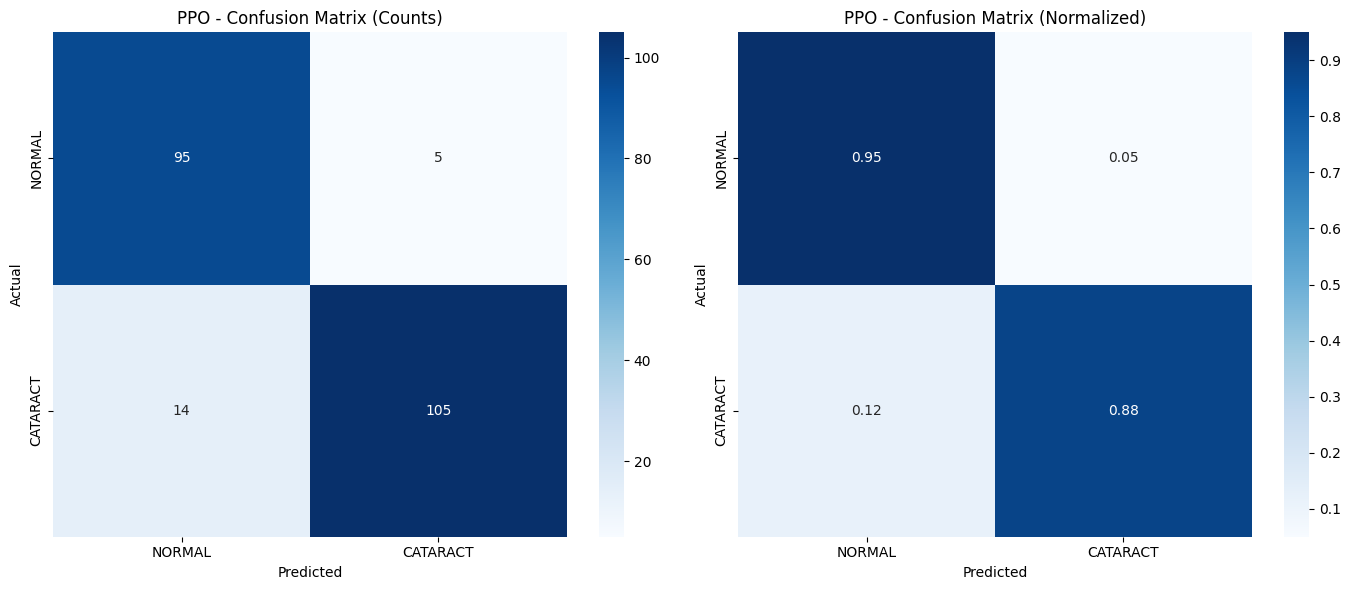

In [58]:
# Confusion Matrix - Counts & Normalized side by side
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','CATARACT'],
            yticklabels=['NORMAL','CATARACT'], ax=axes[0])
axes[0].set_title('PPO - Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['NORMAL','CATARACT'],
            yticklabels=['NORMAL','CATARACT'], ax=axes[1])
axes[1].set_title('PPO - Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [59]:
# Classification Report
from sklearn.metrics import classification_report
print('\nPPO - Classification Report:')
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'CATARACT']))


PPO - Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.87      0.95      0.91       100
    CATARACT       0.95      0.88      0.92       119

    accuracy                           0.91       219
   macro avg       0.91      0.92      0.91       219
weighted avg       0.92      0.91      0.91       219



### ROC Curve

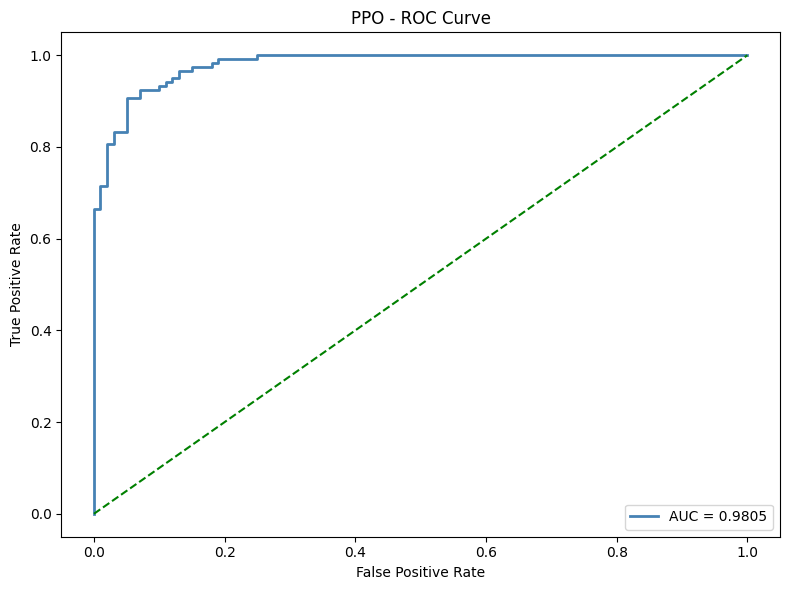

In [60]:
# ROC Curve
from sklearn.metrics import roc_curve, auc as sk_auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc     = sk_auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='green', linestyle='--')
plt.title('PPO - ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Error Analysis

<Figure size 800x600 with 0 Axes>

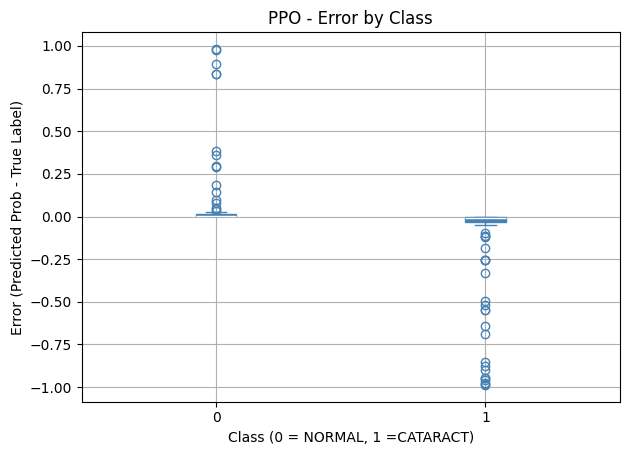

In [61]:
# Error by Class (box plot)
errors   = y_pred_prob - y_true
error_df = pd.DataFrame({'Error': errors, 'Class': y_true})

plt.figure(figsize=(8, 6))
error_df.boxplot(column='Error', by='Class', patch_artist=True,
                 boxprops=dict(facecolor='steelblue', color='steelblue'),
                 medianprops=dict(color='white'),
                 whiskerprops=dict(color='steelblue'),
                 capprops=dict(color='steelblue'),
                 flierprops=dict(markerfacecolor='none', markeredgecolor='steelblue'))
plt.title('PPO - Error by Class')
plt.suptitle('')
plt.xlabel('Class (0 = NORMAL, 1 =CATARACT)')
plt.ylabel('Error (Predicted Prob - True Label)')
plt.tight_layout()
plt.show()

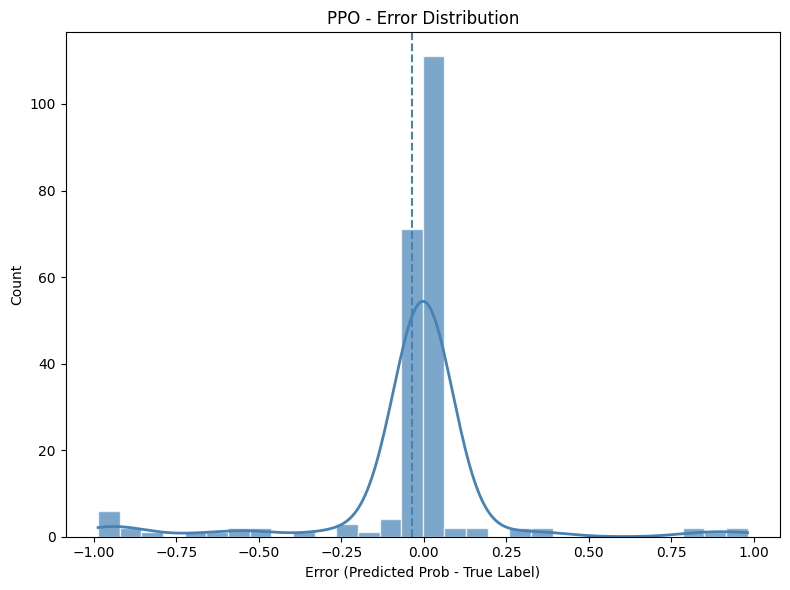

In [62]:
# Error Distribution
from scipy.stats import gaussian_kde

errors = y_pred_prob - y_true
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
kde_x = np.linspace(errors.min(), errors.max(), 300)
kde_y = gaussian_kde(errors)(kde_x) * len(errors) * (errors.max() - errors.min()) / 30
plt.plot(kde_x, kde_y, color='steelblue', lw=2)
plt.axvline(errors.mean(), color='steelblue', linestyle='--')
plt.title('PPO - Error Distribution')
plt.xlabel('Error (Predicted Prob - True Label)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Prediction Probability & Scatter

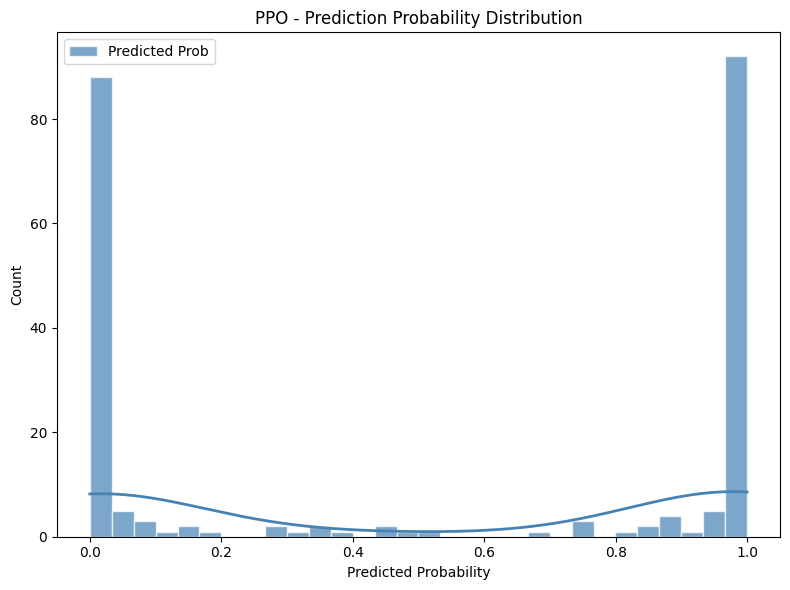

In [63]:
# Prediction Probability Distribution
from scipy.stats import gaussian_kde

probs = y_pred_prob
plt.figure(figsize=(8, 6))
plt.hist(probs, bins=30, alpha=0.7, color='steelblue', edgecolor='white', label='Predicted Prob')
kde_x = np.linspace(0, 1, 300)
kde_y = gaussian_kde(probs)(kde_x) * len(probs) * (1 / 30)
plt.plot(kde_x, kde_y, color='steelblue', lw=2)
plt.title('PPO - Prediction Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

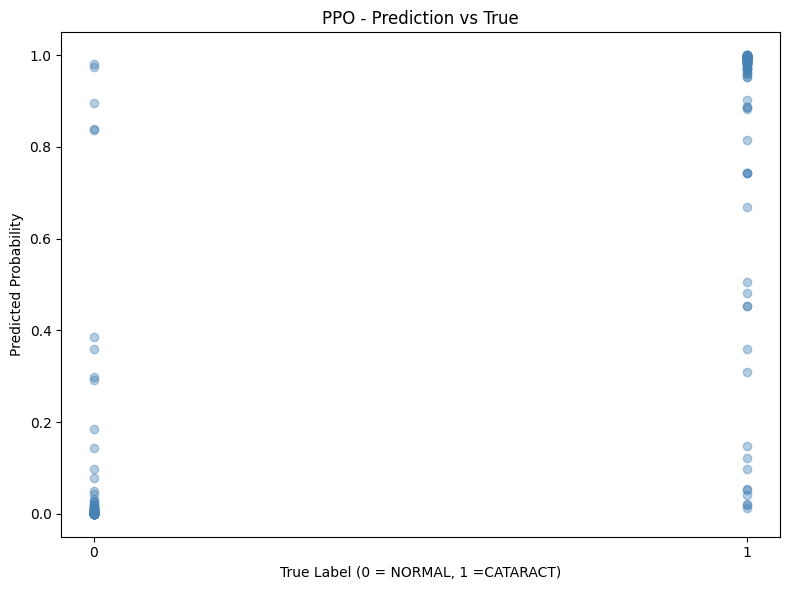

In [64]:
# Prediction vs True (scatter)
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred_prob, alpha=0.4, color='steelblue')
plt.title('PPO - Prediction vs True')
plt.xlabel('True Label (0 = NORMAL, 1 =CATARACT)')
plt.ylabel('Predicted Probability')
plt.xticks([0, 1])
plt.tight_layout()
plt.show()

<h3>Prediction: Actual vs Predicted</h3>

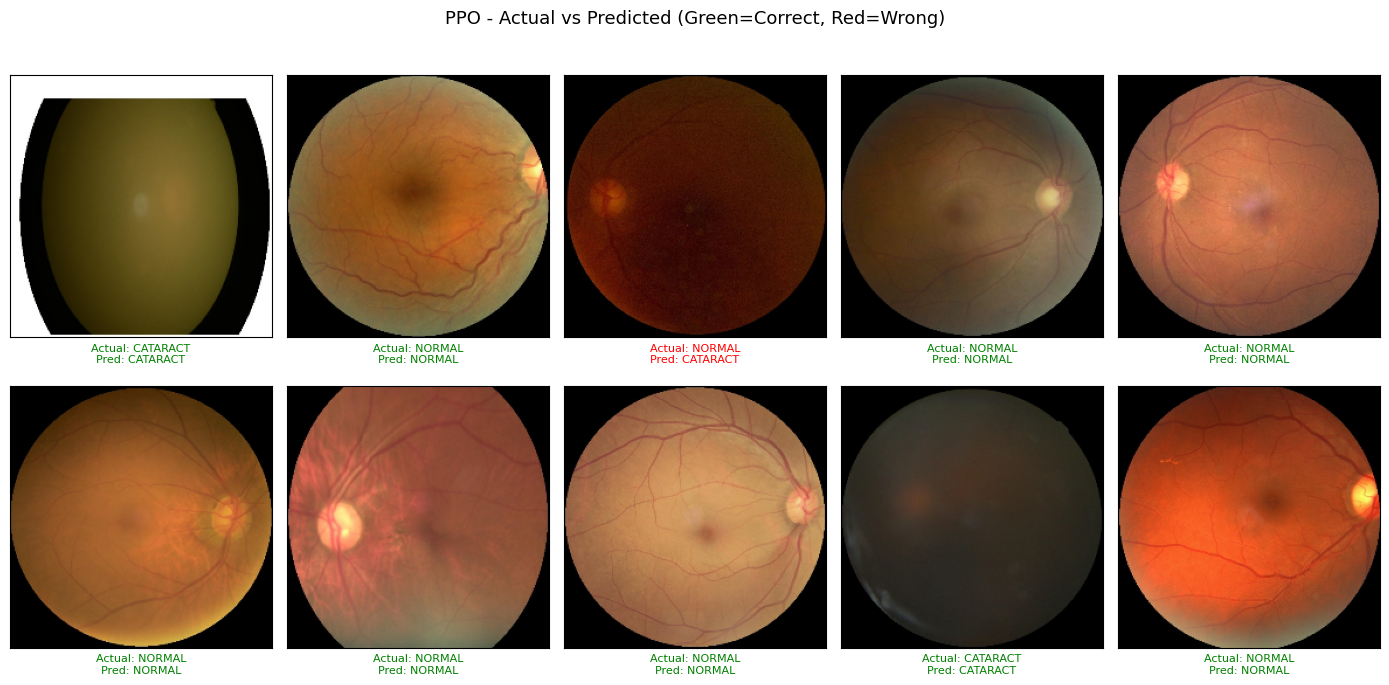

In [68]:
# Visualise predictions on validation images
val_paths = val_df['filename'].reset_index(drop=True).values
class_map = {0: 'NORMAL', 1: 'CATARACT'}
plt.figure(figsize=(14, 7))

# Pick random indices
indices = random.sample(range(len(val_paths)), 10)

for plot_i, idx in enumerate(indices):
    image = cv2.imread(val_paths[idx])
    
    # --- FIX: Check if image exists before processing ---
    if image is None:
        # If image is missing, show a black placeholder so the loop doesn't crash
        image = np.zeros((224, 224, 3), dtype=np.uint8)
        actual = "MISSING"
        predicted = "N/A"
        color = 'gray'
    else:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        actual = class_map[y_true[idx]]
        predicted = class_map[y_pred[idx]]
        color = 'green' if actual == predicted else 'red'
    
    plt.subplot(2, 5, plot_i + 1)
    plt.imshow(image)
    plt.xlabel(f'Actual: {actual}\nPred: {predicted}', color=color, fontsize=8)
    plt.xticks([]); plt.yticks([])

plt.suptitle('PPO - Actual vs Predicted (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.show()

In [66]:
# Calculate final accuracy percentage
final_accuracy = val_acc * 100

print("-" * 30)
print(f"FINAL MODEL ANALYSIS")
print("-" * 30)
print(f"Overall Accuracy: {final_accuracy:.2f}%")
print(f"Total Val Samples: {len(val_labels_arr)}")
print("-" * 30)

------------------------------
FINAL MODEL ANALYSIS
------------------------------
Overall Accuracy: 91.32%
Total Val Samples: 219
------------------------------
